# 03 — Machine-Learning Models for Nav1.7 Potency Prediction

## Overview

This notebook develops and evaluates quantitative structure–activity relationship (QSAR) models for predicting Nav1.7 inhibitory potency from molecular descriptors.

The analysis uses the 6,738 GOOD-quality compounds prepared and characterized in the previous notebooks. Experimental activity is represented as **pIC₅₀**, which serves as the continuous prediction target. Eleven molecular descriptors describing molecular size, lipophilicity, polarity, hydrogen bonding, flexibility, ring composition, and structural complexity are considered as candidate predictive features.

Three modeling approaches are evaluated:

1. **Linear QSAR** — provides an interpretable baseline for estimating the extent to which potency can be explained by linear combinations of molecular descriptors.
2. **Random Forest Regression** — captures nonlinear relationships and interactions among molecular properties using an ensemble of decision trees.
3. **XGBoost Regression** — uses gradient-boosted decision trees to model more complex structure–activity relationships.

Model performance is evaluated using a consistent validation framework and the same performance metrics across models, including **R², root mean squared error (RMSE), and mean absolute error (MAE)**. Cross-validation results are reported as **mean ± standard deviation** to assess both predictive performance and model stability.

Feature-importance analyses are used to examine which molecular descriptors contribute most strongly to predictive performance. Detailed interpretation of the final XGBoost model using SHAP is reserved for `04_model_interpretation.ipynb`.

## Modeling Objective

The objective of this notebook is to determine whether combining multiple molecular descriptors improves prediction of Nav1.7 inhibitory potency beyond the individual descriptor relationships observed during exploratory analysis, and to compare the performance of linear and nonlinear QSAR approaches.

## 1. Load Modeling Dataset

The modeling dataset exported from `02_exploratory_analysis.ipynb` is loaded for QSAR model development.

The dataset contains 6,738 GOOD-quality compounds, their experimental Nav1.7 activity values, data-quality metadata, and 11 molecular descriptors. Only the molecular descriptors are used as predictive features, while pIC₅₀ serves as the continuous prediction target.

In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate

In [23]:
# ============================================================
# GLOBAL PLOT COLOR SCHEME
# ============================================================

# Primary plotting colors
COLOR_PRIMARY = '#4C78A8'      # Main blue
COLOR_SECONDARY = '#72A0C1'    # Secondary/light blue
COLOR_DARK = '#304F5B'         # Dark slate
COLOR_TREND = '#555555'        # Regression/trend lines
COLOR_ERROR = '#222222'        # Error bars and outlines

# Potency progression: weak → very potent
POTENCY_COLORS = [
    '#B8C9D6',   # Weak
    '#8EABC0',   # Medium
    '#5F83A3',   # Potent
    '#304F5B'    # Very Potent
]

In [4]:
# Upload the modeling dataset exported from Notebook 02
uploaded = files.upload()

# Identify the uploaded file
file_name = list(uploaded.keys())[0]

# Load the dataset
modeling_df = pd.read_csv(
    io.BytesIO(uploaded[file_name])
)

print(f"Loaded: {file_name}")
print(
    f"Dataset dimensions: "
    f"{modeling_df.shape[0]:,} rows × {modeling_df.shape[1]} columns"
)

display(modeling_df.head())

Saving nav17_good_modeling_dataset.csv to nav17_good_modeling_dataset.csv
Loaded: nav17_good_modeling_dataset.csv
Dataset dimensions: 6,738 rows × 22 columns


,molecule_chembl_id,canonical_smiles,ic50_nm,pIC50,min_val,max_val,measurement_count,max_min_ratio,data_quality,confidence_level,...,LogP,TPSA,HBA,HBD,RotatableBonds,RingCount,AromaticRings,FractionCSP3,HeavyAtoms,Heteroatoms
0,CHEMBL3904041,C#Cc1cccc(OC2CN(c3ncnc(Nc4cccc(C(=O)NC)c4)n3)C...,990.0,6.004365,990.0,990.0,1,1.000000,GOOD,LOW,...,2.2237,92.27,7.0,2.0,6.0,4.0,3.0,0.181818,30.0,8.0
1,CHEMBL3662199,C/C=C/c1cc(C(=O)NS(=O)(=O)N2CCC2)c(F)cc1OCC12C...,6.0,8.221849,6.0,6.0,1,1.000000,GOOD,LOW,...,4.1343,75.71,4.0,1.0,7.0,6.0,1.0,0.625000,32.0,8.0
2,CHEMBL190461,C=C(C)[C@@H]1CCC(C)=C[C@H]1c1c(O)cc(CCCCC)cc1O,1820.0,5.739929,1820.0,1820.0,1,1.000000,GOOD,LOW,...,5.8465,40.46,2.0,2.0,6.0,2.0,1.0,0.523810,23.0,2.0
3,CHEMBL3955581,C=C(C)c1ccccc1N1CCOc2cc(S(=O)(=O)Nc3nccs3)ccc21,2420.0,5.616185,2420.0,2420.0,1,1.000000,GOOD,LOW,...,4.5075,71.53,6.0,1.0,5.0,4.0,3.0,0.150000,28.0,8.0
4,CHEMBL5805169,C=C(C)c1cn2c(NS(C)(=O)=O)nnc2cc1OCC12CC3CC(CC(...,51.1,7.291579,51.0,51.2,2,1.003922,GOOD,MEDIUM,...,3.7291,85.59,5.0,1.0,6.0,6.0,2.0,0.619048,29.0,8.0


In [5]:
# Validate the imported modeling dataset
print("--- Modeling Dataset Validation ---")

print(f"Compounds:            {len(modeling_df):,}")
print(f"Columns:              {len(modeling_df.columns)}")
print(f"Duplicate structures: {modeling_df['canonical_smiles'].duplicated().sum():,}")
print(f"Missing values:       {modeling_df.isna().sum().sum():,}")

print("\nColumns:")
print(modeling_df.columns.tolist())

--- Modeling Dataset Validation ---
Compounds:            6,738
Columns:              22
Duplicate structures: 0
Missing values:       0

Columns:
['molecule_chembl_id', 'canonical_smiles', 'ic50_nm', 'pIC50', 'min_val', 'max_val', 'measurement_count', 'max_min_ratio', 'data_quality', 'confidence_level', 'potency_class', 'MW', 'LogP', 'TPSA', 'HBA', 'HBD', 'RotatableBonds', 'RingCount', 'AromaticRings', 'FractionCSP3', 'HeavyAtoms', 'Heteroatoms']


## 2. Modeling Features and Prediction Target

Nav1.7 inhibitory potency, expressed as **pIC₅₀**, is used as the continuous prediction target.

Eleven molecular descriptors calculated in the previous notebook are considered as candidate predictive features. Compound identifiers, SMILES strings, activity-derived variables, potency classifications, and data-quality metadata are excluded from the feature matrix to prevent target leakage.

A fixed 80/20 train–test split is created before model fitting or model-specific feature selection. The training set is used for model development and cross-validation, while the held-out test set is reserved for final evaluation.

In [6]:
# Define prediction target
target = 'pIC50'

# Define candidate molecular descriptors
candidate_features = [
    'MW',
    'LogP',
    'TPSA',
    'HBA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'AromaticRings',
    'FractionCSP3',
    'HeavyAtoms',
    'Heteroatoms'
]

# Construct feature matrix and target vector
X = modeling_df[candidate_features].copy()
y = modeling_df[target].copy()

print(f"Feature matrix: {X.shape[0]:,} compounds × {X.shape[1]} descriptors")
print(f"Target: {target}")

Feature matrix: 6,738 compounds × 11 descriptors
Target: pIC50


## 2. Modeling Dataset and Validation Strategy

Nav1.7 inhibitory potency, expressed as **pIC₅₀**, is used as the continuous prediction target. Eleven molecular descriptors are initially considered as candidate predictive features:

- MW
- LogP
- TPSA
- HBA
- HBD
- RotatableBonds
- RingCount
- AromaticRings
- FractionCSP3
- HeavyAtoms
- Heteroatoms

Compound identifiers, SMILES strings, activity-derived variables, potency classifications, and data-quality metadata are excluded from the predictive feature matrix to prevent target leakage.

The 6,738-compound dataset is divided into **80% training data and 20% held-out test data** using a fixed random seed for reproducibility. The same train–test split is retained for all models evaluated in this notebook.

Model development and cross-validation are performed using only the training set. Five-fold cross-validation is used to estimate predictive performance and model stability during development. The held-out test set is reserved for final evaluation and is not used for feature selection, model fitting, or cross-validation.

Model performance is evaluated using **R²**, **root mean squared error (RMSE)**, and **mean absolute error (MAE)**.

In [7]:
# Create a reproducible 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("--- Train/Test Split ---")
print(f"Training compounds: {len(X_train):,} ({len(X_train) / len(X):.1%})")
print(f"Test compounds:     {len(X_test):,} ({len(X_test) / len(X):.1%})")

--- Train/Test Split ---
Training compounds: 5,390 (80.0%)
Test compounds:     1,348 (20.0%)


## 3. Reduced Linear QSAR Model

A multiple linear regression model is first developed as an interpretable QSAR baseline for predicting Nav1.7 inhibitory potency.

Unlike the nonlinear models evaluated later, linear regression is sensitive to multicollinearity among predictors. The exploratory analysis identified substantial correlations and elevated Variance Inflation Factors (VIFs) among several of the 11 molecular descriptors, particularly descriptors representing related aspects of molecular size, polarity, and ring composition.

### 3.1 Chemistry-Informed Descriptor Reduction

To reduce redundancy while preserving chemically distinct information, a representative descriptor was selected for each major physicochemical concept:

- **MW:** molecular size
- **LogP:** lipophilicity
- **TPSA:** molecular polarity
- **HBD:** hydrogen-bond donation
- **RotatableBonds:** molecular flexibility
- **RingCount:** ring topology
- **FractionCSP3:** saturation and three-dimensional character

Four descriptors were excluded from the reduced linear model because they substantially overlap with retained descriptors representing related chemical information:

- **HeavyAtoms:** strongly associated with molecular size and highly correlated with MW
- **Heteroatoms:** overlaps with molecular size, polarity, and heteroatom-related descriptors
- **HBA:** substantially associated with TPSA and other measures of molecular polarity
- **AromaticRings:** overlaps with ring composition and is strongly related to FractionCSP3 in this dataset

This reduction is intended to improve the stability and interpretability of the linear regression coefficients rather than to identify a universally optimal feature subset. The excluded descriptors are therefore not considered chemically unimportant and remain available to the nonlinear Random Forest and XGBoost models.

To preserve the independence of the held-out test set, multicollinearity of the reduced feature set is evaluated using only the training data. VIF values are recalculated after descriptor reduction to determine the remaining degree of redundancy among the seven retained predictors.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Define chemistry-informed reduced descriptor set
reduced_features = [
    'MW',
    'LogP',
    'TPSA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'FractionCSP3'
]

# Select reduced descriptors from the training set only
X_train_reduced = X_train[reduced_features].copy()
X_test_reduced = X_test[reduced_features].copy()

# Add intercept temporarily for VIF calculation
X_vif = sm.add_constant(X_train_reduced)

# Calculate VIF for each retained descriptor
reduced_vif = pd.DataFrame({
    'Descriptor': reduced_features,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(1, X_vif.shape[1])
    ]
})

# Sort from highest to lowest VIF
reduced_vif = reduced_vif.sort_values(
    'VIF',
    ascending=False
).reset_index(drop=True)

print("--- VIF After Chemistry-Informed Descriptor Reduction ---")
display(reduced_vif.round(2))

--- VIF After Chemistry-Informed Descriptor Reduction ---


,Descriptor,VIF
0,MW,3.51
1,TPSA,3.46
2,LogP,3.21
3,FractionCSP3,2.09
4,RotatableBonds,1.71
5,HBD,1.67
6,RingCount,1.33


### Reduced-Set Multicollinearity Assessment

After chemistry-informed descriptor reduction, all seven retained descriptors showed VIF values below 5, with the highest values observed for MW (3.51), TPSA (3.46), and LogP (3.21).

This represents a substantial reduction in multicollinearity compared with the original 11-descriptor feature space, in which MW and HeavyAtoms had VIF values above 10. The remaining VIF values indicate that the reduced descriptors retain related chemical information without exhibiting severe multicollinearity.

The seven-descriptor feature set was therefore retained for the linear QSAR model without further reduction.

### 3.2 Reduced Linear QSAR Equation

A multiple linear regression model is fitted using the seven retained molecular descriptors and the compounds in the training set. Nav1.7 inhibitory potency, expressed as **pIC₅₀**, is used as the continuous response variable.

The model takes the general form:

**pIC₅₀ = β₀ + β₁(MW) + β₂(LogP) + β₃(TPSA) + β₄(HBD) + β₅(RotatableBonds) + β₆(RingCount) + β₇(FractionCSP3)**

where β₀ represents the intercept and each β coefficient represents the estimated contribution of its corresponding molecular descriptor while the remaining descriptors are held constant.

The model is fitted exclusively on the training set. Predictive generalizability is evaluated separately using five-fold cross-validation in the following section.

In [9]:
# Add intercept for statsmodels linear regression
X_train_sm = sm.add_constant(X_train_reduced)

# Fit reduced linear QSAR using training data only
linear_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

# Extract fitted coefficients
params = linear_model.params

# Construct readable QSAR equation
equation_terms = [f"{params['const']:.3f}"]

for feature in reduced_features:
    coefficient = params[feature]
    sign = "+" if coefficient >= 0 else "-"

    equation_terms.append(
        f"{sign} {abs(coefficient):.4f}({feature})"
    )

print("--- Reduced Linear QSAR Equation ---")
print("pIC₅₀ = " + " ".join(equation_terms))

print("\n--- Linear Regression Summary ---")
print(linear_model.summary())

--- Reduced Linear QSAR Equation ---
pIC₅₀ = 1.987 + 0.0046(MW) + 0.3082(LogP) + 0.0048(TPSA) + 0.1779(HBD) - 0.0409(RotatableBonds) + 0.0582(RingCount) + 1.4670(FractionCSP3)

--- Linear Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                  pIC50   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     284.9
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        02:17:40   Log-Likelihood:                -6933.8
No. Observations:                5390   AIC:                         1.388e+04
Df Residuals:                    5382   BIC:                         1.394e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         

#### Initial Model Fit

The fitted reduced linear QSAR model produced a training-set **R² of 0.270** and an adjusted **R² of 0.269**, indicating that the seven retained descriptors collectively explain approximately 27% of the variation in pIC₅₀ within the training data.

Positive coefficients were obtained for MW, LogP, TPSA, HBD, RingCount, and FractionCSP3, whereas RotatableBonds showed a negative coefficient. These coefficients represent conditional associations within the multivariable model and should not be interpreted as independent causal effects of individual molecular properties.

The moderate training-set R² indicates that the linear model captures meaningful but incomplete information about Nav1.7 inhibitory potency. Its predictive stability and generalizability are evaluated next using five-fold cross-validation.

### 3.3 Five-Fold Cross-Validation

The training set is evaluated using **five-fold cross-validation** to assess the predictive performance and stability of the reduced linear QSAR model beyond its fit to the full training data.

The 5,390 training compounds are randomly divided into five folds using a fixed random seed for reproducibility. In each iteration, the model is fitted on four folds and evaluated on the remaining fold. This process is repeated five times so that each compound serves once as validation data.

Performance is evaluated using three complementary regression metrics:

- **R²:** proportion of variation in pIC₅₀ explained by the model
- **RMSE:** root mean squared prediction error, which gives greater weight to larger errors
- **MAE:** mean absolute prediction error

Results are reported as **mean ± standard deviation** across the five validation folds.

The held-out test set is not used during cross-validation and remains reserved for final model evaluation.

In [10]:
# Define reproducible 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the reduced linear QSAR model
linear_cv_model = LinearRegression()

# Perform cross-validation using the training set only
linear_cv_results = cross_validate(
    linear_cv_model,
    X_train_reduced,
    y_train,
    cv=cv,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    }
)

# Extract validation scores
linear_cv_r2 = linear_cv_results['test_r2']
linear_cv_rmse = -linear_cv_results['test_rmse']
linear_cv_mae = -linear_cv_results['test_mae']

# Report individual fold results
linear_cv_summary = pd.DataFrame({
    'Fold': range(1, 6),
    'R²': linear_cv_r2,
    'RMSE': linear_cv_rmse,
    'MAE': linear_cv_mae
})

print("--- Reduced Linear QSAR: 5-Fold Cross-Validation ---")
display(linear_cv_summary.round(3))

print("--- Mean ± SD Cross-Validation Performance ---")
print(f"R²:   {linear_cv_r2.mean():.3f} ± {linear_cv_r2.std():.3f}")
print(f"RMSE: {linear_cv_rmse.mean():.3f} ± {linear_cv_rmse.std():.3f} pIC₅₀ units")
print(f"MAE:  {linear_cv_mae.mean():.3f} ± {linear_cv_mae.std():.3f} pIC₅₀ units")

--- Reduced Linear QSAR: 5-Fold Cross-Validation ---


,Fold,R²,RMSE,MAE
0,1,0.268,0.878,0.708
1,2,0.261,0.876,0.706
2,3,0.275,0.880,0.702
3,4,0.271,0.878,0.702
4,5,0.261,0.873,0.695


--- Mean ± SD Cross-Validation Performance ---
R²:   0.267 ± 0.006
RMSE: 0.877 ± 0.003 pIC₅₀ units
MAE:  0.703 ± 0.005 pIC₅₀ units


#### Cross-Validation Results

Five-fold cross-validation produced a mean **R² of 0.267 ± 0.006**, **RMSE of 0.877 ± 0.003 pIC₅₀ units**, and **MAE of 0.703 ± 0.005 pIC₅₀ units**.

Performance was highly consistent across the five validation folds. R² values ranged from 0.261 to 0.275, while RMSE and MAE varied only slightly between folds. The cross-validated mean R² was also close to the full training-set R² of 0.270, indicating limited evidence of overfitting within the reduced linear model.

However, the cross-validated R² of approximately 0.27 indicates that most of the observed variation in Nav1.7 inhibitory potency is not captured by a simple linear combination of the seven selected molecular descriptors. This provides a baseline against which the nonlinear Random Forest and XGBoost models can be evaluated.

## 4. Random Forest QSAR Model

The reduced seven-descriptor feature set established in the linear QSAR analysis was retained for Random Forest modeling:

- Molecular Weight (MW)
- LogP
- Topological Polar Surface Area (TPSA)
- Hydrogen-Bond Donors (HBD)
- Rotatable Bonds
- Ring Count
- Fraction Csp3

Using the same descriptor set across models provides a controlled comparison between modeling approaches. Differences in predictive performance can therefore be attributed primarily to differences in model structure rather than to differences in the available molecular information.

Unlike multiple linear regression, Random Forest regression does not assume that molecular descriptors have linear or additive relationships with inhibitory potency. Instead, an ensemble of decision trees can capture nonlinear relationships, threshold effects, and interactions among descriptors.

This is particularly relevant to molecular properties such as lipophilicity, where biological activity may depend on an optimal range rather than increasing or decreasing monotonically with the descriptor.

The Random Forest model was evaluated using the same cross-validation framework used for the reduced linear QSAR model. Model performance was assessed using R², root mean squared error (RMSE), and mean absolute error (MAE). Feature importance was subsequently examined to determine which molecular descriptors contributed most strongly to Random Forest predictions.

### 4.1 Random Forest Five-Fold Cross-Validation

The Random Forest model was evaluated using the same **seven molecular descriptors**, training compounds, and five-fold cross-validation splits used for the reduced linear QSAR model. This maintains a controlled comparison in which the primary difference between the models is the learning algorithm rather than the input feature set.

In each fold, the Random Forest model is trained on four-fifths of the training data and evaluated on the remaining fifth. Performance is assessed using **R², RMSE, and MAE**, with results reported as mean ± standard deviation across the five validation folds.

The held-out test set remains excluded from model fitting and cross-validation and is reserved for final model evaluation.

In [11]:
# ============================================================
# 4.1 Random Forest Five-Fold Cross-Validation
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# Define Random Forest model
rf_cv_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Perform 5-fold cross-validation using the same
# 7 descriptors and folds as the linear QSAR model
rf_cv_results = cross_validate(
    rf_cv_model,
    X_train_reduced,
    y_train,
    cv=cv,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    },
    n_jobs=-1
)

# Extract validation scores
rf_cv_r2 = rf_cv_results['test_r2']
rf_cv_rmse = -rf_cv_results['test_rmse']
rf_cv_mae = -rf_cv_results['test_mae']

# Build fold-by-fold results table
rf_cv_summary = pd.DataFrame({
    'Fold': range(1, 6),
    'R²': rf_cv_r2,
    'RMSE': rf_cv_rmse,
    'MAE': rf_cv_mae
})

print("--- Random Forest QSAR: 5-Fold Cross-Validation ---")
display(rf_cv_summary.round(3))

print("\n--- Mean ± SD Cross-Validation Performance ---")
print(f"R²:   {rf_cv_r2.mean():.3f} ± {rf_cv_r2.std():.3f}")
print(f"RMSE: {rf_cv_rmse.mean():.3f} ± {rf_cv_rmse.std():.3f} pIC₅₀ units")
print(f"MAE:  {rf_cv_mae.mean():.3f} ± {rf_cv_mae.std():.3f} pIC₅₀ units")

--- Random Forest QSAR: 5-Fold Cross-Validation ---


,Fold,R²,RMSE,MAE
0,1,0.540,0.696,0.527
1,2,0.481,0.734,0.546
2,3,0.530,0.709,0.527
3,4,0.525,0.709,0.530
4,5,0.499,0.719,0.536



--- Mean ± SD Cross-Validation Performance ---
R²:   0.515 ± 0.022
RMSE: 0.713 ± 0.013 pIC₅₀ units
MAE:  0.533 ± 0.007 pIC₅₀ units


#### Random Forest Cross-Validation Results

Using the same seven molecular descriptors as the reduced linear QSAR model, the Random Forest model achieved a mean **R² of 0.515 ± 0.022**, **RMSE of 0.713 ± 0.013 pIC₅₀ units**, and **MAE of 0.533 ± 0.007 pIC₅₀ units** across five validation folds.

The Random Forest substantially outperformed the linear QSAR model, which produced a cross-validated R² of 0.267 ± 0.006, RMSE of 0.877 ± 0.003, and MAE of 0.703 ± 0.005 pIC₅₀ units using the same descriptor set and validation folds.

Because both models were evaluated using the same compounds, molecular descriptors, and cross-validation partitions, the improvement cannot be attributed to differences in the available feature information. Instead, the results suggest that nonlinear relationships, descriptor interactions, or threshold-dependent effects contribute substantially to the relationship between these molecular properties and Nav1.7 inhibitory potency.

Performance was also reasonably consistent across folds, with R² values ranging from 0.481 to 0.540. The held-out test set remains unused and reserved for final model evaluation.

In [12]:
# Fit the Random Forest on the complete training set
# using the same 7 descriptors as the linear QSAR model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_reduced, y_train)

print("--- Final Random Forest Training Fit ---")
print(f"Training compounds: {len(X_train_reduced):,}")
print(f"Descriptors:        {X_train_reduced.shape[1]}")
print(f"Trees:              {rf_model.n_estimators}")

--- Final Random Forest Training Fit ---
Training compounds: 5,390
Descriptors:        7
Trees:              100


### 4.2 Random Forest Feature Importance

To examine which molecular descriptors contributed most strongly to the fitted Random Forest model, built-in feature importance was calculated using **mean decrease in impurity (MDI)**.

MDI importance measures the cumulative reduction in prediction error associated with splits involving each descriptor across all trees in the forest. The importance values are normalized so that their sum equals 1, with larger values indicating greater use of a descriptor in the model's decision structure.

Because correlated descriptors may share or redistribute importance, these values should be interpreted as measures of **model reliance rather than independent chemical effects**. In addition, MDI importance can favor continuous variables with many possible split points.

Permutation importance is therefore examined separately in the following section as a complementary measure of descriptor contribution.

In [13]:
# Extract built-in Random Forest feature importances
rf_importances = rf_model.feature_importances_

# Map importance values to the same 7 descriptors used for modeling
rf_importance_df = pd.DataFrame({
    'Descriptor': X_train_reduced.columns,
    'Importance': rf_importances
}).sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Print ranked feature importances
print("--- Random Forest Feature Importances ---")

for _, row in rf_importance_df.iterrows():
    print(
        f"{row['Descriptor']:<18}: "
        f"{row['Importance']:.3f} "
        f"({row['Importance'] * 100:.1f}%)"
    )

print(f"\nTotal importance: {rf_importance_df['Importance'].sum():.3f}")

--- Random Forest Feature Importances ---
MW                : 0.350 (35.0%)
FractionCSP3      : 0.203 (20.3%)
LogP              : 0.168 (16.8%)
TPSA              : 0.133 (13.3%)
RotatableBonds    : 0.067 (6.7%)
RingCount         : 0.042 (4.2%)
HBD               : 0.036 (3.6%)

Total importance: 1.000


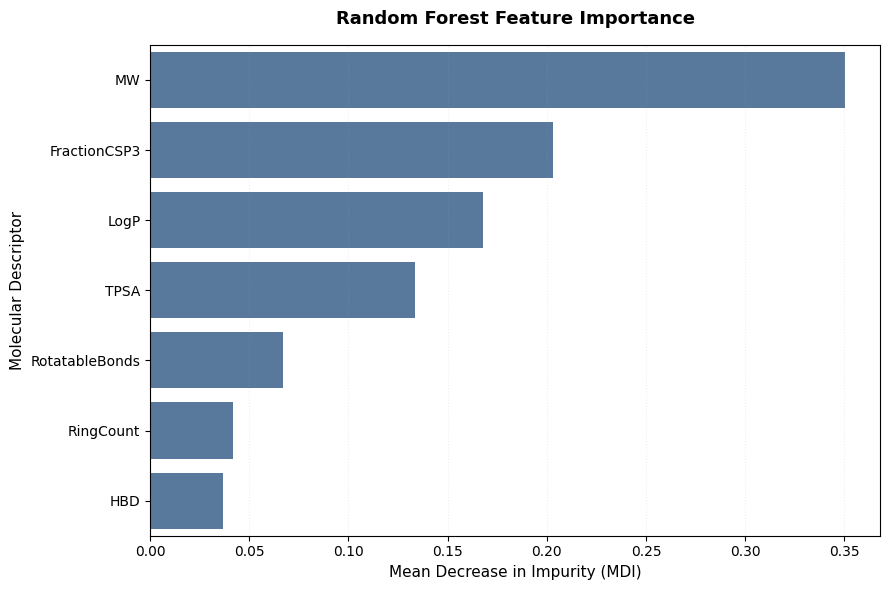

In [14]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=rf_importance_df,
    x='Importance',
    y='Descriptor',
    color=COLOR_PRIMARY
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Mean Decrease in Impurity (MDI)",
    fontsize=11
)
plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)

plt.grid(
    axis='x',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

#### Random Forest Feature Importance Results

Molecular weight (MW) was the most influential descriptor in the fitted Random Forest model, accounting for **35.0%** of the total mean decrease in impurity. Fraction Csp³ (**20.3%**), LogP (**16.8%**), and TPSA (**13.3%**) were the next most important descriptors. Together, these four properties accounted for **85.4%** of the total MDI importance.

The prominence of MW is consistent with the exploratory analysis, where molecular weight showed the strongest individual linear correlation with pIC₅₀ among the selected descriptors.

Fraction Csp³ is particularly notable. Despite showing only a weak direct Pearson correlation with pIC₅₀ in the exploratory analysis, it ranked as the second most important descriptor in the Random Forest model. This suggests that its predictive contribution may arise from nonlinear relationships, threshold effects, or interactions with other molecular properties that are not captured by simple pairwise correlation.

LogP and TPSA also contributed substantially, indicating that lipophilicity and molecular polarity provide important predictive information in addition to molecular size and carbon hybridization.

Because MDI importance reflects how frequently and effectively descriptors are used for tree splitting, it does not establish the direction of their effects or demonstrate independent chemical causation. Permutation importance is therefore examined next as a complementary assessment of model reliance on each descriptor.

### 4.3 Permutation Feature Importance

Permutation feature importance was used as a complementary approach to evaluate how strongly Random Forest predictive performance depends on each molecular descriptor.

Unlike mean decrease in impurity (MDI), permutation importance measures the change in model performance when the values of one descriptor are randomly shuffled while the remaining descriptors are left unchanged. If disrupting a descriptor produces a large decrease in R², the model depends strongly on the information contained in that descriptor.

To avoid using the held-out test set during model interpretation, permutation importance is calculated within the same five-fold cross-validation framework used for model evaluation. For each fold, the model is fitted on four-fifths of the training data and permutation importance is calculated on the remaining validation fold.

This approach provides out-of-sample feature importance estimates while preserving the independent test set for final model evaluation.

In [15]:
# ============================================================
# 4.3 Cross-Validated Permutation Feature Importance
# ============================================================

from sklearn.inspection import permutation_importance

# Store permutation importance from each validation fold
perm_fold_results = []

# Use the exact same 5 CV splits as previous model evaluation
for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train_reduced),
    start=1
):

    # Split the training pool into fold-specific
    # training and validation subsets
    X_fold_train = X_train_reduced.iloc[train_idx]
    X_fold_val = X_train_reduced.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Fit a new Random Forest using only this fold's training data
    rf_fold_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf_fold_model.fit(X_fold_train, y_fold_train)

    # Calculate permutation importance on unseen validation compounds
    perm_result = permutation_importance(
        rf_fold_model,
        X_fold_val,
        y_fold_val,
        n_repeats=10,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )

    # Store mean importance from this fold
    perm_fold_results.append(
        perm_result.importances_mean
    )


# Convert fold results into DataFrame
perm_cv_df = pd.DataFrame(
    perm_fold_results,
    columns=X_train_reduced.columns
)

# Calculate mean ± SD across the five validation folds
perm_summary = pd.DataFrame({
    'Descriptor': X_train_reduced.columns,
    'R2_Drop_Mean': perm_cv_df.mean(axis=0).values,
    'R2_Drop_Std': perm_cv_df.std(axis=0, ddof=0).values
}).sort_values(
    by='R2_Drop_Mean',
    ascending=False
).reset_index(drop=True)


print("--- Cross-Validated Permutation Feature Importance ---")

for _, row in perm_summary.iterrows():
    print(
        f"{row['Descriptor']:<18}: "
        f"{row['R2_Drop_Mean']:.3f} R² "
        f"± {row['R2_Drop_Std']:.3f}"
    )

--- Cross-Validated Permutation Feature Importance ---
MW                : 0.468 R² ± 0.026
FractionCSP3      : 0.240 R² ± 0.017
LogP              : 0.171 R² ± 0.020
TPSA              : 0.091 R² ± 0.012
RotatableBonds    : 0.059 R² ± 0.007
RingCount         : 0.052 R² ± 0.006
HBD               : 0.029 R² ± 0.007


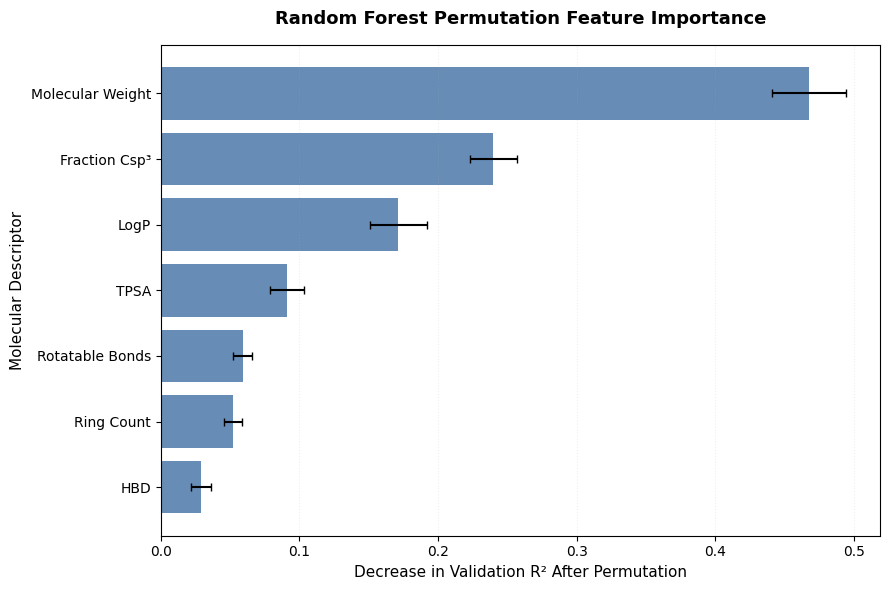

In [16]:
# Chemistry-readable labels
display_names = {
    'MW': 'Molecular Weight',
    'LogP': 'LogP',
    'TPSA': 'TPSA',
    'HBD': 'HBD',
    'RotatableBonds': 'Rotatable Bonds',
    'RingCount': 'Ring Count',
    'FractionCSP3': 'Fraction Csp³'
}

plot_perm = perm_summary.copy()
plot_perm['DisplayName'] = plot_perm['Descriptor'].map(display_names)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_perm['DisplayName'],
    plot_perm['R2_Drop_Mean'],
    xerr=plot_perm['R2_Drop_Std'],
    color=COLOR_PRIMARY,
    alpha=0.85,
    capsize=3
)

plt.gca().invert_yaxis()

plt.title(
    "Random Forest Permutation Feature Importance",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Decrease in Validation R² After Permutation",
    fontsize=11
)
plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)

plt.grid(
    axis='x',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

#### Permutation Feature Importance Results

Cross-validated permutation importance produced the same descriptor ranking as the Random Forest MDI analysis. Molecular weight showed the largest effect, with permutation decreasing validation R² by **0.468 ± 0.026**, followed by Fraction Csp³ (**0.240 ± 0.017**) and LogP (**0.171 ± 0.020**).

TPSA produced a smaller but substantial decrease in predictive performance (**0.091 ± 0.012**), while Rotatable Bonds, Ring Count, and HBD had progressively smaller effects.

The agreement between MDI and permutation importance strengthens the evidence that molecular weight, Fraction Csp³, and LogP are major contributors to Random Forest predictions within the selected seven-descriptor feature space.

Fraction Csp³ remains particularly notable. Its high permutation importance contrasts with its weak pairwise Pearson correlation with pIC₅₀ observed during exploratory analysis. This supports the possibility that Fraction Csp³ contributes predictive information through nonlinear relationships or interactions that are not apparent from simple linear correlation.

Permutation importance measures loss of predictive information when a descriptor is disrupted and does not establish the direction or chemical mechanism of its effect. Descriptor effects and their directionality are examined later using SHAP-based model interpretation.

## 5. XGBoost QSAR Model

Extreme Gradient Boosting (XGBoost) was evaluated as a second nonlinear QSAR approach using the same **seven molecular descriptors**, training compounds, and validation framework used for the reduced linear and Random Forest models.

Unlike Random Forest, which constructs many decision trees independently and combines their predictions, XGBoost builds trees sequentially. Each new tree is trained to improve errors remaining from the preceding trees. This gradient-boosting framework can capture nonlinear relationships, descriptor interactions, and threshold-dependent effects while progressively refining model predictions.

To maintain a controlled comparison among modeling approaches, XGBoost was trained using the same seven chemistry-informed descriptors:

- Molecular Weight (MW)
- LogP
- Topological Polar Surface Area (TPSA)
- Hydrogen-Bond Donors (HBD)
- Rotatable Bonds
- Ring Count
- Fraction Csp³

Model performance was evaluated using the same five-fold cross-validation partitions applied to the linear QSAR and Random Forest models. Predictive performance was assessed using **R², RMSE, and MAE**.

The independent held-out test set remains excluded during model development and cross-validation and is reserved for final comparison of the completed models.

### 5.1 XGBoost Five-Fold Cross-Validation

The XGBoost model was evaluated using the same seven molecular descriptors, training compounds, and five-fold cross-validation partitions used for the reduced linear QSAR and Random Forest models.

A fixed XGBoost configuration (n_estimators = 100, learning_rate = 0.1, max_depth = 6) was specified before evaluation and applied consistently across all five validation folds. No information from the held-out test set was used for model configuration or cross-validation.

Maintaining identical input features and cross-validation partitions allows differences in predictive performance among linear regression, Random Forest, and XGBoost to be attributed primarily to differences in modeling approach.

The independent held-out test set remains excluded from model development and is reserved for final model evaluation.

In [17]:
# ============================================================
# 5.1 XGBoost Five-Fold Cross-Validation
# ============================================================

from xgboost import XGBRegressor

# 1. Define baseline XGBoost model
xgb_cv_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# 2. Perform 5-fold cross-validation using the SAME
# training compounds, 7 descriptors, and CV folds
xgb_cv_results = cross_validate(
    xgb_cv_model,
    X_train_reduced,
    y_train,
    cv=cv,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    },
    n_jobs=-1
)

# 3. Extract validation scores
xgb_cv_r2 = xgb_cv_results['test_r2']
xgb_cv_rmse = -xgb_cv_results['test_rmse']
xgb_cv_mae = -xgb_cv_results['test_mae']

# 4. Build fold-by-fold results table
xgb_cv_summary = pd.DataFrame({
    'Fold': range(1, 6),
    'R²': xgb_cv_r2,
    'RMSE': xgb_cv_rmse,
    'MAE': xgb_cv_mae
})

print("--- XGBoost QSAR: 5-Fold Cross-Validation ---")
display(xgb_cv_summary.round(3))

# 5. Report Mean ± SD
print("\n--- Mean ± SD Cross-Validation Performance ---")
print(f"R²:   {xgb_cv_r2.mean():.3f} ± {xgb_cv_r2.std():.3f}")
print(f"RMSE: {xgb_cv_rmse.mean():.3f} ± {xgb_cv_rmse.std():.3f} pIC₅₀ units")
print(f"MAE:  {xgb_cv_mae.mean():.3f} ± {xgb_cv_mae.std():.3f} pIC₅₀ units")

--- XGBoost QSAR: 5-Fold Cross-Validation ---


,Fold,R²,RMSE,MAE
0,1,0.539,0.697,0.533
1,2,0.495,0.724,0.549
2,3,0.552,0.692,0.524
3,4,0.547,0.692,0.525
4,5,0.509,0.711,0.540



--- Mean ± SD Cross-Validation Performance ---
R²:   0.528 ± 0.022
RMSE: 0.703 ± 0.013 pIC₅₀ units
MAE:  0.534 ± 0.009 pIC₅₀ units


#### XGBoost Cross-Validation Results

Across five validation folds, the XGBoost model achieved a mean **R² of 0.528 ± 0.022**, **RMSE of 0.703 ± 0.013 pIC₅₀ units**, and **MAE of 0.534 ± 0.009 pIC₅₀ units**.

XGBoost substantially outperformed the reduced linear QSAR model and produced performance similar to, but slightly better than, Random Forest in terms of mean R² and RMSE. Random Forest produced a marginally lower mean MAE.

The comparable performance of Random Forest and XGBoost, despite their different tree-learning strategies, supports the conclusion that nonlinear relationships and descriptor interactions contain predictive information not captured by the reduced linear QSAR model.

Performance remained relatively stable across the five validation folds, as indicated by the small standard deviations of all three evaluation metrics.

### 5.2 Final XGBoost Training Model

Following five-fold cross-validation, the XGBoost model was fitted to the complete training set of **5,390 compounds** using the same seven chemistry-informed molecular descriptors and fixed model configuration evaluated during cross-validation.

Training on the complete development set allows the model to use all available training information before final evaluation on the independent held-out test set.

The held-out test compounds were not used during model fitting, cross-validation, or model configuration. They remain reserved for the final comparison of the linear QSAR, Random Forest, and XGBoost models.

In [18]:
# ============================================================
# 5.2 Fit XGBoost on Complete Training Set
# ============================================================

# Define final XGBoost model using the SAME configuration as 5.1
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Fit using all 5,390 training compounds
xgb_model.fit(
    X_train_reduced,
    y_train
)

print("--- Final XGBoost Training Model ---")
print(f"Training compounds: {len(X_train_reduced):,}")
print(f"Number of descriptors: {X_train_reduced.shape[1]}")
print(f"Descriptors: {list(X_train_reduced.columns)}")

print("\nModel configuration:")
print("n_estimators:  100")
print("learning_rate: 0.1")
print("max_depth:     6")

print("\nXGBoost model successfully fitted to the complete training set.")

--- Final XGBoost Training Model ---
Training compounds: 5,390
Number of descriptors: 7
Descriptors: ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

Model configuration:
n_estimators:  100
learning_rate: 0.1
max_depth:     6

XGBoost model successfully fitted to the complete training set.


## 6. Model Performance Comparison

The reduced linear QSAR, Random Forest, and XGBoost models were compared under a common validation framework to evaluate the effect of model complexity on prediction of Nav1.7 inhibitory potency.

All three models were developed using the same:

- **5,390 training compounds**
- **Seven chemistry-informed molecular descriptors**
- **Five cross-validation partitions**
- **Performance metrics: R², RMSE, and MAE**

Maintaining identical compounds, descriptors, and validation folds provides a controlled comparison in which differences in predictive performance primarily reflect differences in modeling approach.

Cross-validation performance is first compared using the mean ± standard deviation across the five validation folds. Following this comparison, each model is evaluated once on the independent **1,348-compound held-out test set**, which has remained excluded from model fitting, cross-validation, feature selection, and model interpretation.

The held-out evaluation provides the final assessment of model generalization to compounds not used during model development.

### 6.1 Five-Fold Cross-Validation Comparison

Cross-validation performance was compared across the reduced linear QSAR, Random Forest, and XGBoost models using the same seven-descriptor feature space and identical five-fold partitions of the 5,390-compound training set.

For each model, predictive performance is summarized as the **mean ± standard deviation** of R², RMSE, and MAE across the five validation folds. Because the compounds, descriptors, validation folds, and evaluation metrics were held constant, this comparison isolates the effect of the modeling approach on predictive performance.

Higher R² and lower RMSE and MAE indicate better predictive performance.

In [19]:
# ============================================================
# 6.1 Five-Fold Cross-Validation Comparison
# ============================================================

# Compile Mean ± SD results from the three completed CV analyses
cv_comparison = pd.DataFrame({
    'Model': [
        'Linear QSAR',
        'Random Forest',
        'XGBoost'
    ],

    'R² Mean': [
        linear_cv_r2.mean(),
        rf_cv_r2.mean(),
        xgb_cv_r2.mean()
    ],
    'R² SD': [
        linear_cv_r2.std(),
        rf_cv_r2.std(),
        xgb_cv_r2.std()
    ],

    'RMSE Mean': [
        linear_cv_rmse.mean(),
        rf_cv_rmse.mean(),
        xgb_cv_rmse.mean()
    ],
    'RMSE SD': [
        linear_cv_rmse.std(),
        rf_cv_rmse.std(),
        xgb_cv_rmse.std()
    ],

    'MAE Mean': [
        linear_cv_mae.mean(),
        rf_cv_mae.mean(),
        xgb_cv_mae.mean()
    ],
    'MAE SD': [
        linear_cv_mae.std(),
        rf_cv_mae.std(),
        xgb_cv_mae.std()
    ]
})

# Create publication-readable Mean ± SD columns
cv_display = pd.DataFrame({
    'Model': cv_comparison['Model'],

    'R² (Mean ± SD)': [
        f"{mean:.3f} ± {sd:.3f}"
        for mean, sd in zip(
            cv_comparison['R² Mean'],
            cv_comparison['R² SD']
        )
    ],

    'RMSE (Mean ± SD)': [
        f"{mean:.3f} ± {sd:.3f}"
        for mean, sd in zip(
            cv_comparison['RMSE Mean'],
            cv_comparison['RMSE SD']
        )
    ],

    'MAE (Mean ± SD)': [
        f"{mean:.3f} ± {sd:.3f}"
        for mean, sd in zip(
            cv_comparison['MAE Mean'],
            cv_comparison['MAE SD']
        )
    ]
})

print("--- Five-Fold Cross-Validation Model Comparison ---")
display(cv_display)

--- Five-Fold Cross-Validation Model Comparison ---


,Model,R² (Mean ± SD),RMSE (Mean ± SD),MAE (Mean ± SD)
0,Linear QSAR,0.267 ± 0.006,0.877 ± 0.003,0.703 ± 0.005
1,Random Forest,0.515 ± 0.022,0.713 ± 0.013,0.533 ± 0.007
2,XGBoost,0.528 ± 0.022,0.703 ± 0.013,0.534 ± 0.009


### 6.2 Final Held-Out Test Set Evaluation

Following completion of model development and cross-validation, the reduced linear QSAR, Random Forest, and XGBoost models were evaluated on the independent **held-out test set of 1,348 compounds**.

The test compounds were excluded from model fitting, descriptor selection, cross-validation, and model interpretation during the preceding analyses. Each model was trained using the complete **5,390-compound training set** and the same seven molecular descriptors before generating predictions for the identical held-out test compounds.

Final predictive performance was assessed using:

- **R²**, measuring the proportion of variance in experimental pIC₅₀ explained by model predictions
- **RMSE**, measuring the typical magnitude of prediction error while giving greater weight to larger errors
- **MAE**, measuring the average absolute difference between predicted and experimental pIC₅₀

Higher R² and lower RMSE and MAE indicate better predictive performance.

This held-out evaluation provides an independent assessment of model generalization and allows comparison with the five-fold cross-validation results obtained during model development. No model parameters or descriptor selections were modified based on test-set performance.

In [20]:
# ============================================================
# 6.2 Final Held-Out Test Set Evaluation
# ============================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Fit the final Linear QSAR model on the complete training set
# ------------------------------------------------------------

# statsmodels requires an explicit intercept column
X_train_linear = sm.add_constant(
    X_train_reduced,
    has_constant='add'
)

X_test_linear = sm.add_constant(
    X_test_reduced,
    has_constant='add'
)

linear_final_model = sm.OLS(
    y_train,
    X_train_linear
).fit()


# ------------------------------------------------------------
# 2. Generate predictions on the SAME held-out test set
# ------------------------------------------------------------

linear_test_pred = linear_final_model.predict(X_test_linear)

rf_test_pred = rf_model.predict(
    X_test_reduced
)

xgb_test_pred = xgb_model.predict(
    X_test_reduced
)


# ------------------------------------------------------------
# 3. Helper function for consistent metric calculation
# ------------------------------------------------------------

def calculate_test_metrics(y_true, y_pred):
    return {
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }


# ------------------------------------------------------------
# 4. Calculate held-out test metrics
# ------------------------------------------------------------

linear_test_metrics = calculate_test_metrics(
    y_test,
    linear_test_pred
)

rf_test_metrics = calculate_test_metrics(
    y_test,
    rf_test_pred
)

xgb_test_metrics = calculate_test_metrics(
    y_test,
    xgb_test_pred
)


# ------------------------------------------------------------
# 5. Compile final comparison table
# ------------------------------------------------------------

test_comparison = pd.DataFrame([
    {
        'Model': 'Linear QSAR',
        **linear_test_metrics
    },
    {
        'Model': 'Random Forest',
        **rf_test_metrics
    },
    {
        'Model': 'XGBoost',
        **xgb_test_metrics
    }
])


# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("--- Final Held-Out Test Set Evaluation ---")
print(f"Test compounds: {len(y_test):,}\n")

display(
    test_comparison.style.format({
        'R²': '{:.3f}',
        'RMSE': '{:.3f}',
        'MAE': '{:.3f}'
    })
)

--- Final Held-Out Test Set Evaluation ---
Test compounds: 1,348



,Model,R²,RMSE,MAE
0,Linear QSAR,0.294,0.887,0.704
1,Random Forest,0.539,0.716,0.534
2,XGBoost,0.549,0.708,0.539


In [21]:
print("Test compounds:", len(X_test_reduced))
print("Test descriptors:", X_test_reduced.shape[1])
print("Descriptors:", X_test_reduced.columns.tolist())

Test compounds: 1348
Test descriptors: 7
Descriptors: ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']


#### Held-Out Test Set Results

Performance on the independent 1,348-compound test set closely agreed with the five-fold cross-validation estimates for all three models.

The reduced linear QSAR model achieved a test **R² of 0.294**, **RMSE of 0.887 pIC₅₀ units**, and **MAE of 0.704 pIC₅₀ units**. Random Forest improved performance to an **R² of 0.539**, **RMSE of 0.716**, and **MAE of 0.534**, while XGBoost achieved an **R² of 0.549**, **RMSE of 0.708**, and **MAE of 0.539**.

The close agreement between cross-validation and held-out test performance indicates that the relative performance of the three modeling approaches generalized to compounds excluded from model development.

Both nonlinear tree-based models substantially outperformed the reduced linear QSAR model. XGBoost produced the highest test R² and lowest RMSE, whereas Random Forest produced a slightly lower MAE. The difference between Random Forest and XGBoost remained small compared with the substantially larger improvement of both nonlinear models over linear regression.

These results support the conclusion that nonlinear relationships and descriptor interactions contribute important predictive information for Nav1.7 inhibitory potency within the selected seven-descriptor chemical feature space.

### 6.3 Predicted vs. Experimental pIC₅₀

To visualize predictive performance beyond the aggregate evaluation metrics, predicted pIC₅₀ values were compared directly with experimentally measured pIC₅₀ values for the **1,348 compounds in the held-out test set**.

Predicted-versus-experimental plots provide a visual assessment of how closely each model reproduces measured Nav1.7 inhibitory potency across the observed activity range. Perfect predictions would fall along the **identity line (predicted pIC₅₀ = experimental pIC₅₀)**, while deviations from this line represent prediction error.

The same held-out compounds are shown for the reduced linear QSAR, Random Forest, and XGBoost models, allowing direct comparison of their prediction patterns. These plots can reveal behavior not fully captured by summary metrics, including systematic overprediction or underprediction, compression of the predicted potency range, and differences in performance at the extremes of experimental activity.

No additional model fitting or parameter adjustment was performed during this analysis; the visualization uses the final held-out predictions generated in Section 6.2.

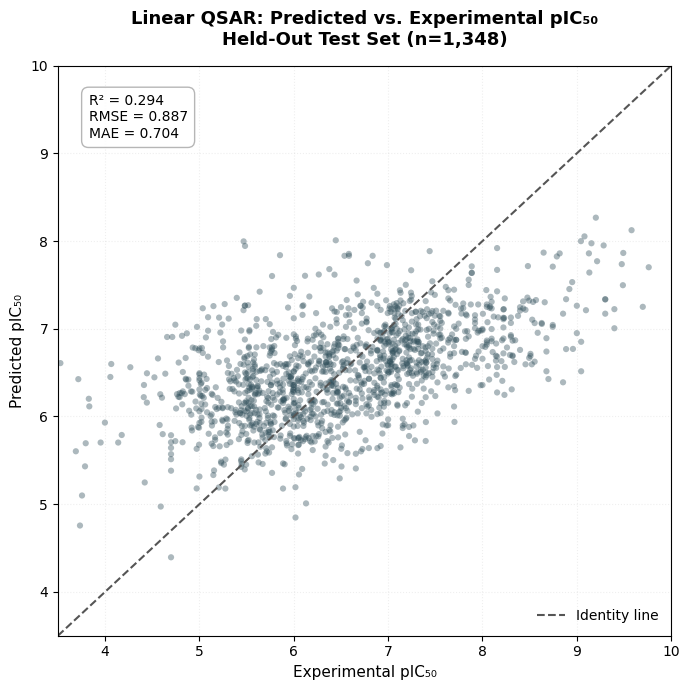

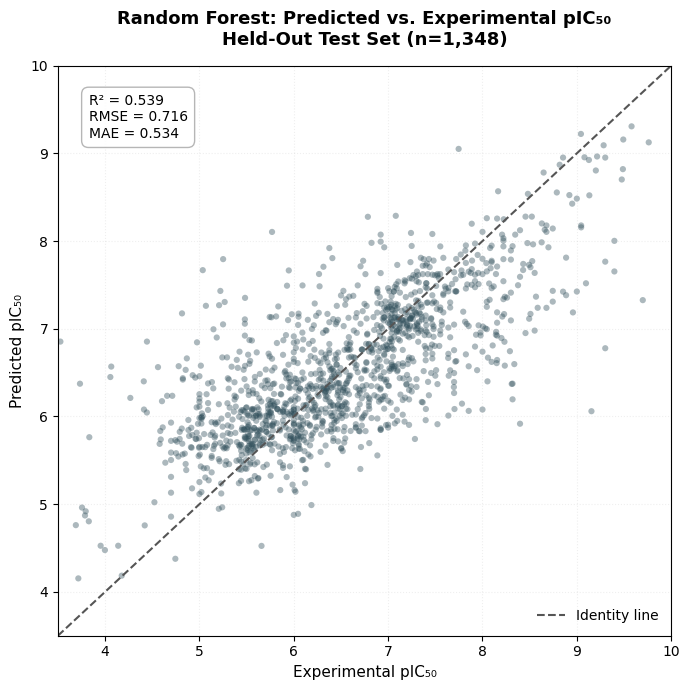

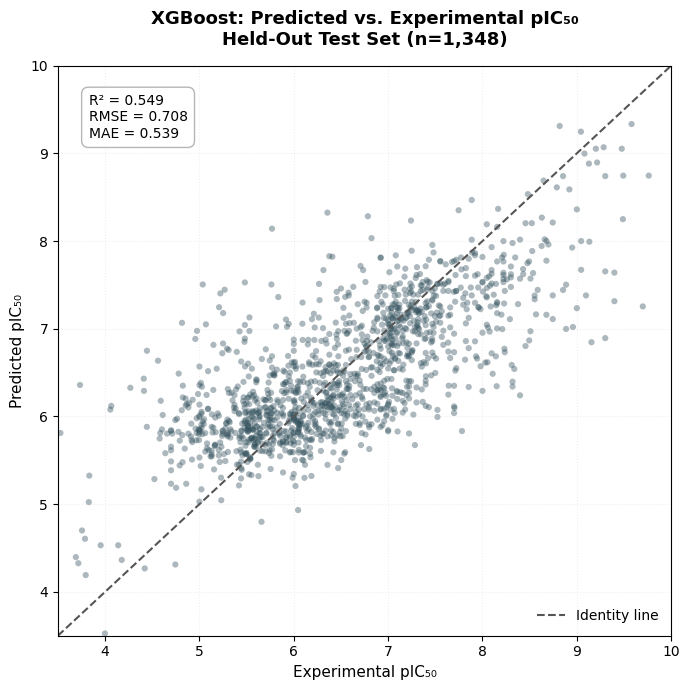

In [24]:
# ============================================================
# 6.3 Predicted vs. Experimental pIC50
# Held-Out Test Set (n = 1,348)
# ============================================================

# 1. Determine common axis limits across experimental and
# predicted values so all three plots are directly comparable
all_values = np.concatenate([
    y_test.to_numpy(),
    np.asarray(linear_test_pred),
    np.asarray(rf_test_pred),
    np.asarray(xgb_test_pred)
])

axis_min = np.floor(all_values.min() * 2) / 2
axis_max = np.ceil(all_values.max() * 2) / 2


# 2. Helper function to generate identically formatted plots
def plot_predicted_vs_experimental(
    y_true,
    y_pred,
    model_name,
    r2,
    rmse,
    mae,
    point_color
):
    plt.figure(figsize=(7, 7))

    # Experimental vs. predicted values
    plt.scatter(
        y_true,
        y_pred,
        s=20,
        alpha=0.40,
        color=point_color,
        edgecolors='none'
    )

    # Identity line: perfect prediction
    plt.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        linestyle='--',
        linewidth=1.5,
        color=COLOR_TREND,
        label='Identity line'
    )

    # Performance statistics
    stats_text = (
        f"R² = {r2:.3f}\n"
        f"RMSE = {rmse:.3f}\n"
        f"MAE = {mae:.3f}"
    )

    plt.gca().text(
        0.05,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='white',
            alpha=0.85,
            edgecolor='#AAAAAA'
        )
    )

    # Identical axes for all models
    plt.xlim(axis_min, axis_max)
    plt.ylim(axis_min, axis_max)

    plt.xlabel(
        "Experimental pIC₅₀",
        fontsize=11
    )

    plt.ylabel(
        "Predicted pIC₅₀",
        fontsize=11
    )

    plt.title(
        f"{model_name}: Predicted vs. Experimental pIC₅₀\n"
        f"Held-Out Test Set (n={len(y_true):,})",
        fontsize=13,
        fontweight='bold',
        pad=15
    )

    plt.grid(
        alpha=0.2,
        linestyle=':'
    )

    plt.legend(
        loc='lower right',
        frameon=False
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Linear QSAR
# ============================================================

plot_predicted_vs_experimental(
    y_test,
    linear_test_pred,
    "Linear QSAR",
    linear_test_metrics['R²'],
    linear_test_metrics['RMSE'],
    linear_test_metrics['MAE'],
    COLOR_DARK
)


# ============================================================
# 4. Random Forest
# ============================================================

plot_predicted_vs_experimental(
    y_test,
    rf_test_pred,
    "Random Forest",
    rf_test_metrics['R²'],
    rf_test_metrics['RMSE'],
    rf_test_metrics['MAE'],
    COLOR_DARK
)


# ============================================================
# 5. XGBoost
# ============================================================

plot_predicted_vs_experimental(
    y_test,
    xgb_test_pred,
    "XGBoost",
    xgb_test_metrics['R²'],
    xgb_test_metrics['RMSE'],
    xgb_test_metrics['MAE'],
    COLOR_DARK
)

#### Predicted vs. Experimental pIC₅₀ Results

The predicted-versus-experimental plots reveal clear differences in the behavior of the three QSAR models.

The reduced linear QSAR model showed substantial compression of predicted values toward the center of the potency distribution. Compounds with low experimental pIC₅₀ were frequently overpredicted, whereas highly potent compounds tended to be underpredicted. This limited ability to reproduce the extremes of the experimental potency range is consistent with its lower held-out R² of **0.294**.

Both nonlinear models showed substantially closer agreement with the identity line and reproduced a broader range of experimental activities. Random Forest achieved a held-out **R² of 0.539**, while XGBoost achieved **R² = 0.549**. The two models displayed similar prediction patterns, consistent with their comparable cross-validation and held-out performance.

Although the nonlinear models improved prediction across the activity range, deviations from the identity line remained, particularly among compounds at the extremes of experimental potency. Thus, the selected seven molecular descriptors capture substantial but incomplete information associated with Nav1.7 inhibitory activity.

Overall, the visual results support the quantitative model comparison: nonlinear tree-based models capture relationships between molecular properties and inhibitory potency that are not adequately represented by the reduced linear QSAR model.

### 6.4 Final Model Assessment

The combined cross-validation, held-out test, and predicted-versus-experimental results were used to assess the relative strengths of the three QSAR modeling approaches and select a model for subsequent chemical interpretation.

Model assessment considered not only overall predictive performance, as measured by **R², RMSE, and MAE**, but also the consistency between cross-validation and independent test performance and the ability of each model to reproduce the observed range of Nav1.7 inhibitory potency.

Particular attention was given to whether the nonlinear Random Forest and XGBoost models provided meaningful improvements over the reduced linear QSAR baseline and whether those improvements generalized to compounds excluded from model development.

The final model selection provides the basis for the model-interpretation analyses conducted in Notebook 04, where descriptor contributions, nonlinear relationships, and their potential chemical significance are examined in greater detail.

In [25]:
# ============================================================
# 6.4 Final Model Assessment
# ============================================================

# 1. Compile cross-validation and held-out test performance
final_assessment = pd.DataFrame({
    'Model': [
        'Linear QSAR',
        'Random Forest',
        'XGBoost'
    ],

    'CV R²': [
        linear_cv_r2.mean(),
        rf_cv_r2.mean(),
        xgb_cv_r2.mean()
    ],

    'Test R²': [
        linear_test_metrics['R²'],
        rf_test_metrics['R²'],
        xgb_test_metrics['R²']
    ],

    'CV RMSE': [
        linear_cv_rmse.mean(),
        rf_cv_rmse.mean(),
        xgb_cv_rmse.mean()
    ],

    'Test RMSE': [
        linear_test_metrics['RMSE'],
        rf_test_metrics['RMSE'],
        xgb_test_metrics['RMSE']
    ],

    'CV MAE': [
        linear_cv_mae.mean(),
        rf_cv_mae.mean(),
        xgb_cv_mae.mean()
    ],

    'Test MAE': [
        linear_test_metrics['MAE'],
        rf_test_metrics['MAE'],
        xgb_test_metrics['MAE']
    ]
})


# 2. Calculate difference between held-out and CV performance
# Positive ΔR² means test R² was higher than mean CV R².
# Positive error Δ means test error was higher than mean CV error.

final_assessment['ΔR² (Test - CV)'] = (
    final_assessment['Test R²'] -
    final_assessment['CV R²']
)

final_assessment['ΔRMSE (Test - CV)'] = (
    final_assessment['Test RMSE'] -
    final_assessment['CV RMSE']
)

final_assessment['ΔMAE (Test - CV)'] = (
    final_assessment['Test MAE'] -
    final_assessment['CV MAE']
)


# 3. Display final assessment table
print("--- Final QSAR Model Assessment ---")

display(
    final_assessment.style.format({
        'CV R²': '{:.3f}',
        'Test R²': '{:.3f}',
        'CV RMSE': '{:.3f}',
        'Test RMSE': '{:.3f}',
        'CV MAE': '{:.3f}',
        'Test MAE': '{:.3f}',
        'ΔR² (Test - CV)': '{:+.3f}',
        'ΔRMSE (Test - CV)': '{:+.3f}',
        'ΔMAE (Test - CV)': '{:+.3f}'
    })
)


# 4. Identify models with strongest held-out performance
best_r2_model = final_assessment.loc[
    final_assessment['Test R²'].idxmax(),
    'Model'
]

best_rmse_model = final_assessment.loc[
    final_assessment['Test RMSE'].idxmin(),
    'Model'
]

best_mae_model = final_assessment.loc[
    final_assessment['Test MAE'].idxmin(),
    'Model'
]


print("\n--- Held-Out Performance Leaders ---")
print(f"Highest R²:  {best_r2_model}")
print(f"Lowest RMSE: {best_rmse_model}")
print(f"Lowest MAE:  {best_mae_model}")


# 5. Report selected model for subsequent interpretation
selected_model = 'XGBoost'

print("\n--- Model Selected for Notebook 04 ---")
print(selected_model)
print(
    "Selected based on the highest held-out R² and lowest held-out RMSE, "
    "while recognizing that Random Forest produced comparable performance."
)

--- Final QSAR Model Assessment ---


,Model,CV R²,Test R²,CV RMSE,Test RMSE,CV MAE,Test MAE,ΔR² (Test - CV),ΔRMSE (Test - CV),ΔMAE (Test - CV)
0,Linear QSAR,0.267,0.294,0.877,0.887,0.703,0.704,+0.026,+0.010,+0.001
1,Random Forest,0.515,0.539,0.713,0.716,0.533,0.534,+0.025,+0.003,+0.001
2,XGBoost,0.528,0.549,0.703,0.708,0.534,0.539,+0.021,+0.005,+0.005



--- Held-Out Performance Leaders ---
Highest R²:  XGBoost
Lowest RMSE: XGBoost
Lowest MAE:  Random Forest

--- Model Selected for Notebook 04 ---
XGBoost
Selected based on the highest held-out R² and lowest held-out RMSE, while recognizing that Random Forest produced comparable performance.


#### Final Model Assessment Results

The final assessment showed strong agreement between five-fold cross-validation and independent held-out test performance for all three QSAR models. Differences between mean cross-validation and test performance were small, indicating that the relative performance observed during model development generalized well to the 1,348 compounds excluded from training.

The reduced linear QSAR model achieved a cross-validated R² of **0.267** and a held-out R² of **0.294**. In comparison, Random Forest achieved **0.515** and **0.539**, while XGBoost achieved **0.528** and **0.549**, respectively. Both nonlinear models therefore provided substantial improvements over the linear baseline.

Prediction-error metrics showed the same general pattern. XGBoost produced the lowest held-out RMSE (**0.708 pIC₅₀ units**) and highest held-out R² (**0.549**), whereas Random Forest produced the lowest held-out MAE (**0.534 pIC₅₀ units**). The performance difference between Random Forest and XGBoost was small, indicating that both tree-based approaches captured similar predictive information from the seven-descriptor feature space.

The predicted-versus-experimental analysis further showed that the linear model compressed predictions toward the center of the potency distribution, particularly underpredicting highly potent compounds and overpredicting compounds at the low-potency end. Random Forest and XGBoost reproduced a broader range of experimental activities, although prediction errors remained at the extremes of the potency distribution.

Overall, these results indicate that the relationship between the selected molecular descriptors and Nav1.7 inhibitory potency is not adequately described by a simple linear model. The improved performance of both tree-based approaches supports the presence of nonlinear relationships and/or descriptor interactions within the chemical feature space.

**XGBoost was selected for subsequent model interpretation** because it produced the highest held-out R² and lowest held-out RMSE. However, its advantage over Random Forest was modest, and the two models should be regarded as having broadly comparable predictive performance. XGBoost interpretation in Notebook 04 will therefore focus on understanding how individual molecular descriptors contribute to predicted potency rather than treating the model as a complete mechanistic description of Nav1.7 inhibition.

## 8. Export Data for Model Interpretation

The finalized seven-descriptor modeling dataset was exported for use in Notebook 04. The exported file retains compound identifiers, molecular structures, experimental pIC₅₀ values, and the seven chemistry-informed descriptors used consistently across the linear QSAR, Random Forest, and XGBoost models.

Notebook 04 uses this dataset to reconstruct the fixed XGBoost modeling framework and perform model-interpretation analyses without modifying the descriptor selection or model configuration established during Notebook 03.

In [27]:
# ============================================================
# Export Modeling Dataset for Notebook 04
# ============================================================

# 1. Select compound information, target, and the final
#    seven chemistry-informed descriptors
interpretation_columns = [
    'molecule_chembl_id',
    'canonical_smiles',
    'pIC50',
    'MW',
    'LogP',
    'TPSA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'FractionCSP3'
]

interpretation_df = modeling_df[
    interpretation_columns
].copy()


# ------------------------------------------------------------
# 2. Preserve the EXACT train/test assignment from Notebook 03
# ------------------------------------------------------------

interpretation_df['DatasetSplit'] = 'Unassigned'

interpretation_df.loc[
    X_train_reduced.index,
    'DatasetSplit'
] = 'Train'

interpretation_df.loc[
    X_test_reduced.index,
    'DatasetSplit'
] = 'Test'


# ------------------------------------------------------------
# 3. Audit the dataset BEFORE export
# ------------------------------------------------------------

print("--- Notebook 04 Export Audit ---")

print(f"Total compounds:    {len(interpretation_df):,}")

print(
    f"Training compounds: "
    f"{(interpretation_df['DatasetSplit'] == 'Train').sum():,}"
)

print(
    f"Test compounds:     "
    f"{(interpretation_df['DatasetSplit'] == 'Test').sum():,}"
)

print(
    f"Unassigned:         "
    f"{(interpretation_df['DatasetSplit'] == 'Unassigned').sum():,}"
)

print("\nMissing values:")
print(interp_missing := interpretation_df.isnull().sum())

print("\nColumns:")
print(interpretation_df.columns.tolist())


# ------------------------------------------------------------
# 4. Safety checks
# ------------------------------------------------------------

assert len(interpretation_df) == 6738, \
    "Unexpected total number of compounds."

assert (interpretation_df['DatasetSplit'] == 'Train').sum() == 5390, \
    "Training-set count does not match Notebook 03."

assert (interpretation_df['DatasetSplit'] == 'Test').sum() == 1348, \
    "Test-set count does not match Notebook 03."

assert (interpretation_df['DatasetSplit'] == 'Unassigned').sum() == 0, \
    "Some compounds were not assigned to Train or Test."

assert interpretation_df.isnull().sum().sum() == 0, \
    "Missing values detected in interpretation dataset."

print("\nAll export safety checks passed.")


# ------------------------------------------------------------
# 5. Save CSV
# ------------------------------------------------------------

filename = "nav17_model_interpretation_data.csv"

interpretation_df.to_csv(
    filename,
    index=False
)

print(f"\nSaved: {filename}")


# ------------------------------------------------------------
# 6. Download to local computer — Google Colab
# ------------------------------------------------------------

from google.colab import files

files.download(filename)

--- Notebook 04 Export Audit ---
Total compounds:    6,738
Training compounds: 5,390
Test compounds:     1,348
Unassigned:         0

Missing values:
molecule_chembl_id    0
canonical_smiles      0
pIC50                 0
MW                    0
LogP                  0
TPSA                  0
HBD                   0
RotatableBonds        0
RingCount             0
FractionCSP3          0
DatasetSplit          0
dtype: int64

Columns:
['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3', 'DatasetSplit']

All export safety checks passed.

Saved: nav17_model_interpretation_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>